# Honeybee vs Bumblebee Classification — Deep Learning


## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
import pandas as pd

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ── Paths & Hyperparameters ──────────────────────────────────────
TRAIN_DIR   = '../data/processed/train'
TEST_DIR    = '../data/processed/test'
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

## 2. Load Datasets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_DIR = "/content/drive/MyDrive/data/processed/train"
TEST_DIR = "/content/drive/MyDrive/data/processed/test"

In [5]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='training',
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=SEED
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print('Classes:', class_names)

Found 1323 files belonging to 2 classes.
Using 1059 files for training.
Found 1323 files belonging to 2 classes.
Using 264 files for validation.
Found 331 files belonging to 2 classes.
Classes: ['bumblebee', 'honeybee']


  Class                 Train     Test
  bumblebee               661      166
  honeybee                662      165
  TOTAL                  1323      331

  Batch size      : 32
  Batches / epoch : 34
  Image size      : (224, 224)


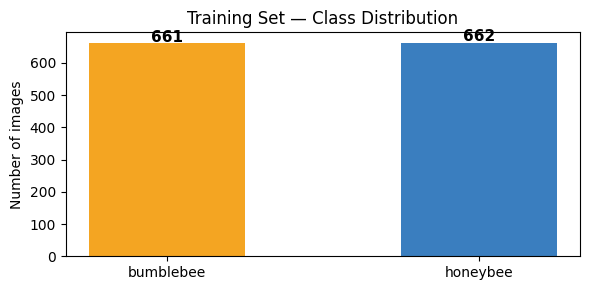

In [6]:
# ── Dataset Exploration ───────────────────────────────────────────
import pathlib

train_path = pathlib.Path(TRAIN_DIR)
test_path  = pathlib.Path(TEST_DIR)

print("=" * 50)
print(f"  {'Class':<18} {'Train':>8}   {'Test':>6}")
print("=" * 50)
total_train, total_test = 0, 0
for cls in class_names:
    tr = len(list(train_path.glob(f'{cls}/*')))
    te = len(list(test_path.glob(f'{cls}/*')))
    total_train += tr
    total_test  += te
    print(f"  {cls:<18} {tr:>8}   {te:>6}")
print("=" * 50)
print(f"  {'TOTAL':<18} {total_train:>8}   {total_test:>6}")
print(f"\n  Batch size      : {BATCH_SIZE}")
print(f"  Batches / epoch : {len(train_ds_raw)}")
print(f"  Image size      : {IMAGE_SIZE}")
print("=" * 50)

# Class distribution bar chart
counts = {cls: len(list(train_path.glob(f'{cls}/*'))) for cls in class_names}
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(counts.keys(), counts.values(),
              color=['#F4A522', '#3A7EBF'], width=0.5)
ax.set_title('Training Set — Class Distribution')
ax.set_ylabel('Number of images')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Augmentation & Preprocessing

> **Why augmentation?** With only ~1300 images, augmentation artificially expands the dataset and helps prevent overfitting by showing the model different variations of the same image.

In [7]:
# Augmentation layers (applied only during training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),        # bees are never upside-down
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.1),
], name='data_augmentation')

# MobileNetV2 expects inputs scaled to [-1, 1]
def preprocess(image, label):
    return preprocess_input(image), label

def augment_and_preprocess(image, label):
    image = data_augmentation(image, training=True)
    return preprocess_input(image), label

train_ds = (train_ds_raw
            .cache()                                                   # ← cache RAW images first
            .map(augment_and_preprocess, num_parallel_calls=AUTOTUNE) # ← then augment freshly every epoch
            .prefetch(AUTOTUNE))
val_ds   = val_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print('Datasets ready.')

Datasets ready.


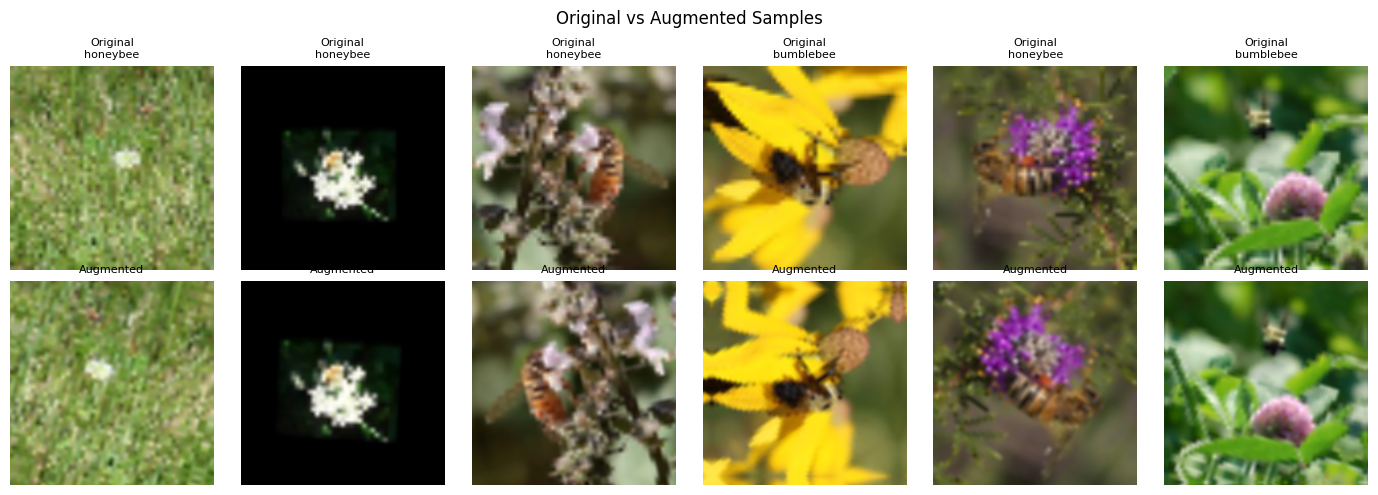

In [8]:
# Visualize original vs augmented samples
plt.figure(figsize=(14, 5))
for images, labels in train_ds_raw.take(1):
    for i in range(6):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(f'Original\n{class_names[labels[i]]}', fontsize=8)
        plt.axis('off')

        ax = plt.subplot(2, 6, i + 7)
        aug = data_augmentation(tf.expand_dims(images[i], 0), training=True)
        plt.imshow(aug[0].numpy().astype('uint8'))
        plt.title('Augmented', fontsize=8)
        plt.axis('off')

plt.suptitle('Original vs Augmented Samples', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Build the Model

**Architecture:**
```
Input (224×224×3)
  → MobileNetV2 backbone  ← pre-trained on ImageNet
  → GlobalAveragePooling2D
  → BatchNormalization
  → Dense(256, relu) → Dropout(0.4)
  → Dense(128, relu) → Dropout(0.3)
  → Dense(1, sigmoid)   ← binary output
```

> **Why sigmoid + 1 unit?** Binary classification. Outputs probability of class 1 (bumblebee). Threshold 0.5 → prediction.

In [9]:
def build_model(trainable_backbone=False, unfreeze_from_layer=None):
    """
    Build MobileNetV2-based transfer learning model.

    Args:
        trainable_backbone  : if True, backbone layers can be trained
        unfreeze_from_layer : layer name to start unfreezing from (fine-tuning)
    """
    backbone = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = trainable_backbone

    # Phase 2: selectively unfreeze top layers
    if trainable_backbone and unfreeze_from_layer:
        set_trainable = False
        for layer in backbone.layers:
            if layer.name == unfreeze_from_layer:
                set_trainable = True
            layer.trainable = set_trainable
        trainable_count = sum(1 for l in backbone.layers if l.trainable)
        print(f'Trainable backbone layers: {trainable_count}')

    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = backbone(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs)

## 5. Phase 1 — Train Head Only (Backbone Frozen)

> The backbone weights are frozen. Only the Dense layers on top are trained. This prevents the randomly-initialized head from destroying ImageNet weights.

In [10]:
model = build_model(trainable_backbone=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
# Class Weights — handle imbalanced dataset
from sklearn.utils.class_weight import compute_class_weight

# Collect all training labels from the raw (un-augmented) dataset
all_labels = np.concatenate([y.numpy() for _, y in train_ds_raw])

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights:")
for k, v in class_weight_dict.items():
    print(f"  {class_names[k]:<15} → {v:.4f}")

Class weights:
  bumblebee       → 0.9916
  honeybee        → 1.0086


In [12]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

history1 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict      # handles class imbalance
)

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.6302 - auc: 0.6712 - loss: 0.7323
Epoch 1: val_accuracy improved from None to 0.76515, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.6846 - auc: 0.7507 - loss: 0.6556 - val_accuracy: 0.7652 - val_auc: 0.8907 - val_loss: 0.5034 - learning_rate: 0.0010
Epoch 2/30
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8049 - auc: 0.8844 - loss: 0.4378
Epoch 2: val_accuracy improved from 0.76515 to 0.79167, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 328ms/step - accuracy: 0.8045 - auc: 0.8881 - loss: 0.4287 - val_accuracy: 0.7917 - val_auc: 0.8957 - val_loss: 0.4625 - learning_rate: 0.0010
Epoch 3/30
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8193 - auc: 0.9069 - loss: 0.3879
Epoch 3: val_accuracy improved from 0.79167 to 0

## 6. Phase 2 — Fine-Tune Top Backbone Layers

> We unfreeze MobileNetV2 layers from `block_12_expand` onward (~30 layers). Using a very small learning rate (1e-5) to gently adapt these layers to bee-specific features without destroying ImageNet knowledge.

**Why fine-tune?** Frozen ImageNet features are generic (edges, textures). Fine-tuning adapts the top layers to learn bee-specific patterns like fuzz, stripes, and wing shapes.

In [13]:
FINE_TUNE_FROM = 'block_12_expand'   # unfreeze more layers than before

# Modify the SAME model in-place — do NOT rebuild
# This preserves all BatchNorm statistics from Phase 1 training.
backbone = model.layers[1]   # MobileNetV2 is the 2nd layer
backbone.trainable = True

set_trainable = False
for layer in backbone.layers:
    if layer.name == FINE_TUNE_FROM:
        set_trainable = True
    layer.trainable = set_trainable

n_trainable = sum(1 for l in backbone.layers if l.trainable)
n_frozen    = sum(1 for l in backbone.layers if not l.trainable)
print(f"Backbone — Trainable layers: {n_trainable}  |  Frozen layers: {n_frozen}")

# MUST recompile after changing trainable flags
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

Backbone — Trainable layers: 47  |  Frozen layers: 107


In [14]:
callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss',
                      factor=0.5,
                      patience=6,
                      min_lr=1e-7,
                      verbose=1)
]

history2 = model.fit(
    train_ds,
    epochs=40,
    validation_data=val_ds,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict  # handles class imbalance
)

Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.7972 - auc: 0.8823 - loss: 0.4415
Epoch 1: val_accuracy improved from None to 0.83712, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 57s 916ms/step - accuracy: 0.7932 - auc: 0.8733 - loss: 0.4566 - val_accuracy: 0.8371 - val_auc: 0.9206 - val_loss: 0.3671 - learning_rate: 1.0000e-05
Epoch 2/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.8038 - auc: 0.8855 - loss: 0.4343
Epoch 2: val_accuracy improved from 0.83712 to 0.84091, saving model to best_model_phase2.keras

Epoch 2: finished saving model to best_model_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.8121 - auc: 0.8920 - loss: 0.4210 - val_accuracy: 0.8409 - val_auc: 0.9263 - val_loss: 0.3521 - learning_rate: 1.0000e-05
Epoch 3/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.7812 - auc: 0.8736 - loss: 0.4595
Epoch 3: val_accuracy improved from 0

## 7. Training Curves

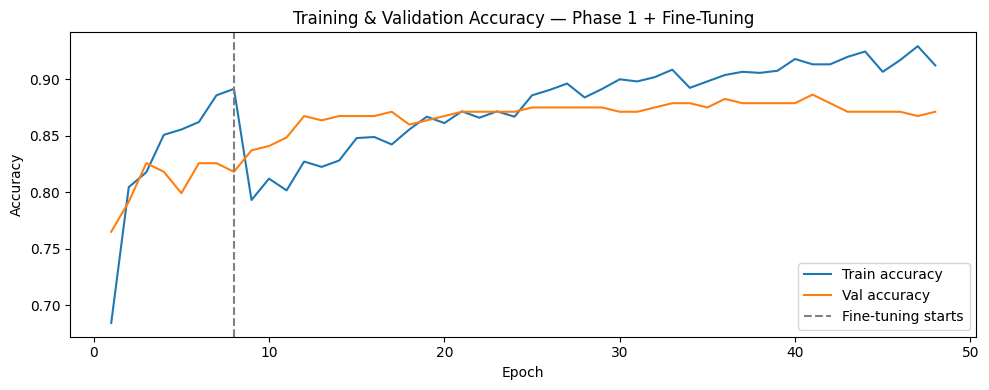

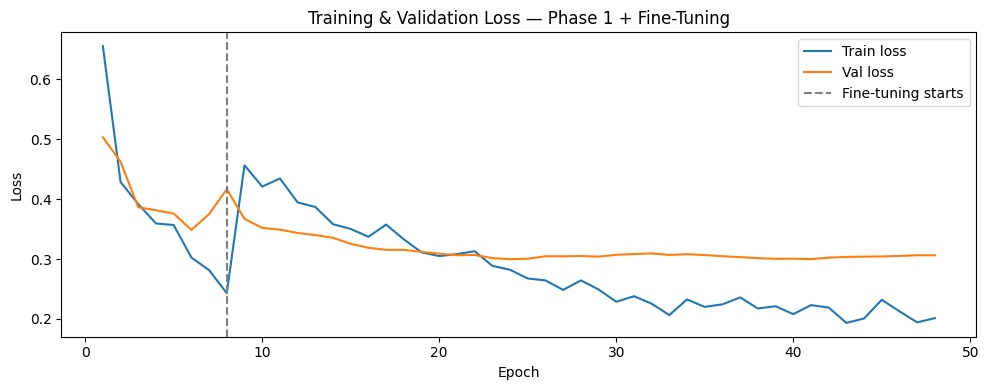

In [15]:
def plot_history(h1, h2, metric='accuracy'):
    """Plot combined Phase 1 + Phase 2 training curves."""
    combined     = h1.history[metric]     + h2.history[metric]
    combined_val = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    epochs_total = range(1, len(combined) + 1)
    phase2_start = len(h1.history[metric])

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_total, combined,     label=f'Train {metric}')
    plt.plot(epochs_total, combined_val, label=f'Val {metric}')
    plt.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tuning starts')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.title(f'Training & Validation {metric.capitalize()} — Phase 1 + Fine-Tuning')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history1, history2, 'accuracy')
plot_history(history1, history2, 'loss')

                    Phase                               Strategy  Epochs run Best val acc Best val AUC     Gain
Phase 1 — Frozen backbone               Head layers trained only           8       0.8258       0.9269 baseline
     Phase 2 — Fine-tuned Backbone unfrozen from block_12_expand          40       0.8864       0.9478   +6.06%


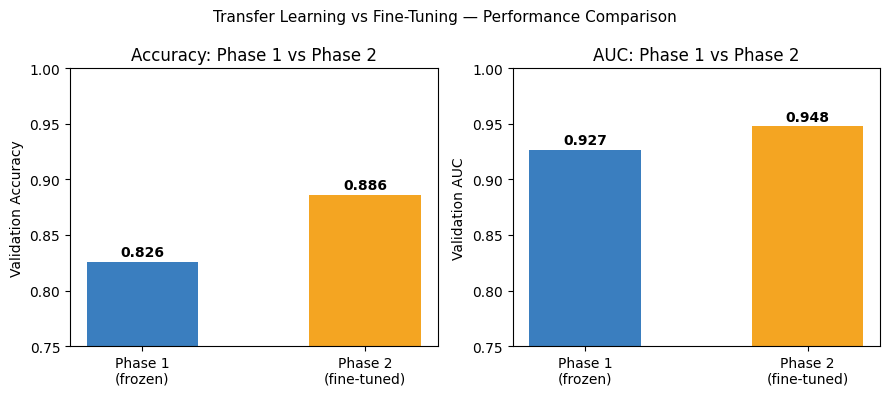

In [16]:
# Phase 1 vs Phase 2 — Summary Comparison
p1_best_acc = max(history1.history['val_accuracy'])
p1_best_auc = max(history1.history['val_auc'])
p2_best_acc = max(history2.history['val_accuracy'])
p2_best_auc = max(history2.history['val_auc'])
p1_epochs   = len(history1.history['val_accuracy'])
p2_epochs   = len(history2.history['val_accuracy'])

summary_df = pd.DataFrame({
    'Phase'       : ['Phase 1 — Frozen backbone',
                     'Phase 2 — Fine-tuned'],
    'Strategy'    : ['Head layers trained only',
                     f'Backbone unfrozen from {FINE_TUNE_FROM}'],
    'Epochs run'  : [p1_epochs, p2_epochs],
    'Best val acc': [f'{p1_best_acc:.4f}', f'{p2_best_acc:.4f}'],
    'Best val AUC': [f'{p1_best_auc:.4f}', f'{p2_best_auc:.4f}'],
    'Gain'        : ['baseline',
                     f'+{(p2_best_acc - p1_best_acc) * 100:.2f}%'],
})
print(summary_df.to_string(index=False))

# Side-by-side bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
phases = ['Phase 1\n(frozen)', 'Phase 2\n(fine-tuned)']
colors = ['#3A7EBF', '#F4A522']

ax1.bar(phases, [p1_best_acc, p2_best_acc], color=colors, width=0.5)
ax1.set_ylim(0.75, 1.0)
ax1.set_ylabel('Validation Accuracy')
ax1.set_title('Accuracy: Phase 1 vs Phase 2')
for i, v in enumerate([p1_best_acc, p2_best_acc]):
    ax1.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

ax2.bar(phases, [p1_best_auc, p2_best_auc], color=colors, width=0.5)
ax2.set_ylim(0.75, 1.0)
ax2.set_ylabel('Validation AUC')
ax2.set_title('AUC: Phase 1 vs Phase 2')
for i, v in enumerate([p1_best_auc, p2_best_auc]):
    ax2.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Transfer Learning vs Fine-Tuning — Performance Comparison',
             fontsize=11)
plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

In [17]:
y_true, y_prob = [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

test_acc = np.mean(y_pred == y_true)
print(f'Test Accuracy: {test_acc:.4f}\n')
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

Test Accuracy: 0.8731

Classification Report:
              precision    recall  f1-score   support

   bumblebee       0.89      0.85      0.87       166
    honeybee       0.86      0.90      0.88       165

    accuracy                           0.87       331
   macro avg       0.87      0.87      0.87       331
weighted avg       0.87      0.87      0.87       331



## 9. Confusion Matrix

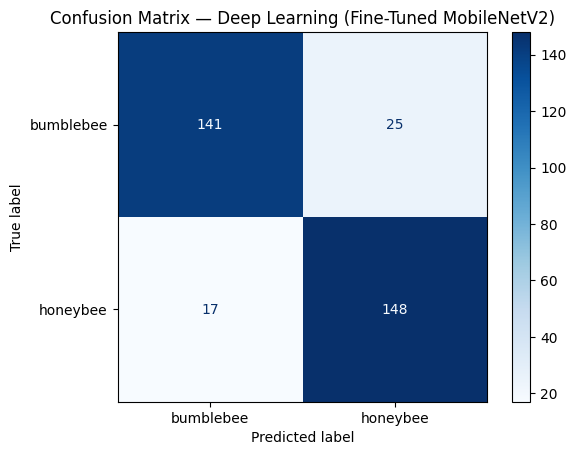

In [18]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Deep Learning (Fine-Tuned MobileNetV2)')
plt.show()

## 10. ROC Curve

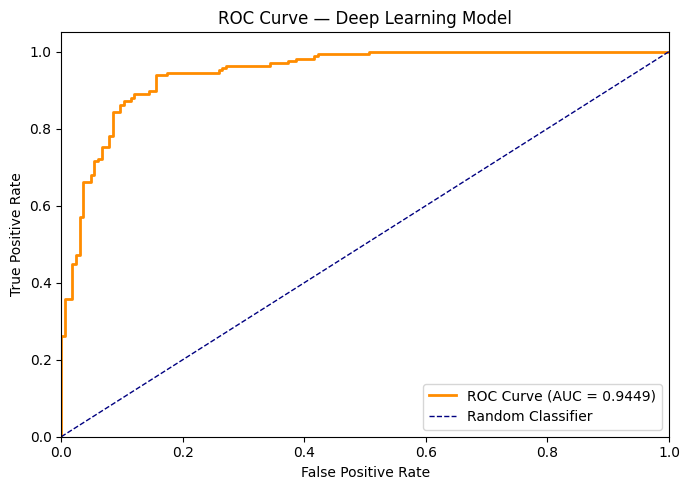

In [19]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Deep Learning Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 11. Visualize Predictions on Test Images

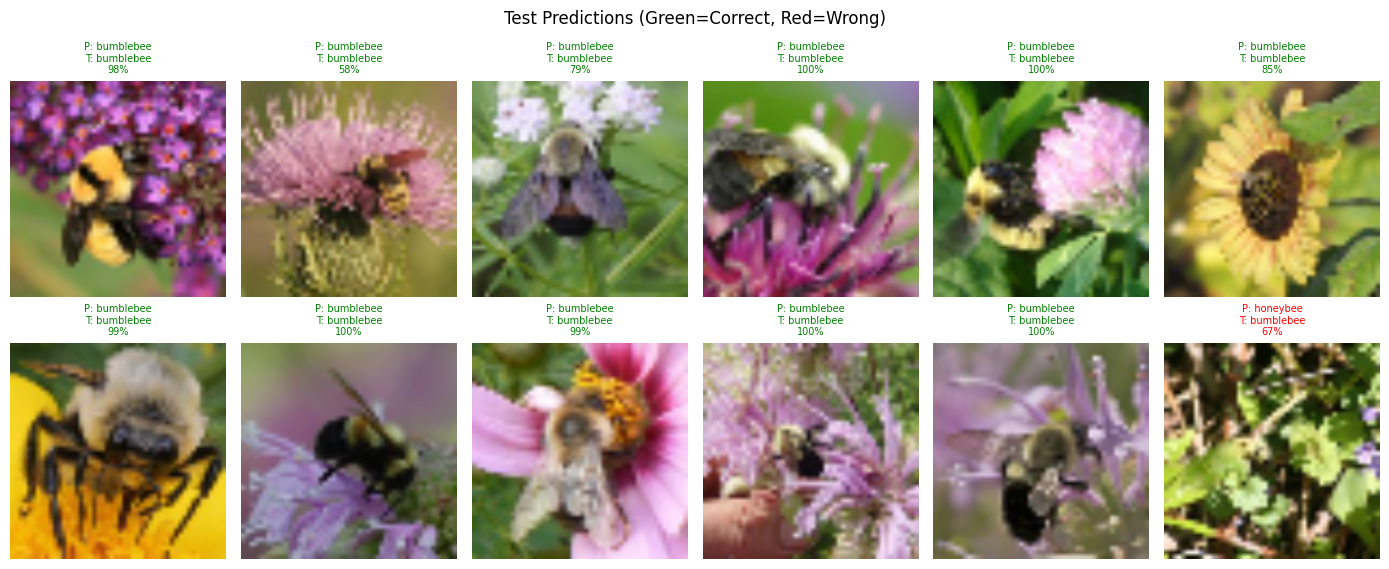

In [20]:
plt.figure(figsize=(14, 6))
for images, labels in test_ds_raw.take(1):
    preprocessed = preprocess_input(tf.cast(images, tf.float32))
    probs = model.predict(preprocessed, verbose=0).flatten()

    for i in range(min(12, len(images))):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        pred_label = class_names[int(probs[i] >= 0.5)]
        true_label = class_names[labels[i]]
        color = 'green' if pred_label == true_label else 'red'
        confidence = probs[i] if int(probs[i] >= 0.5) == 1 else 1 - probs[i]
        plt.title(f'P: {pred_label}\nT: {true_label}\n{confidence:.0%}',
                  fontsize=7, color=color)
        plt.axis('off')

plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 12. ResNet50 — Second Backbone for Comparison

> **Why ResNet50?** ResNet50 uses skip connections (residual connections) that solve the vanishing gradient problem, allowing 50 layers to train effectively. It has 25M parameters vs MobileNetV2's 3.4M — a fundamentally different architecture that trades efficiency for accuracy.
>
> We apply the exact same two-phase training strategy to ensure a fair comparison.

In [30]:
#  ResNet50 needs its own preprocessing function
# Each backbone has a specific pixel scaling it was trained with.
#  ResNet50 expects BGR mean-subtracted.


from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def resnet_preprocess_fn(image, label):
    return resnet_preprocess(tf.cast(image, tf.float32)), label

def resnet_augment_fn(image, label):
    image = data_augmentation(image, training=True)
    return resnet_preprocess(tf.cast(image, tf.float32)), label

train_ds_r50 = (train_ds_raw
                .cache()
                .map(resnet_augment_fn, num_parallel_calls=AUTOTUNE)
                .prefetch(AUTOTUNE))

val_ds_r50   = (val_ds_raw
                .map(resnet_preprocess_fn, num_parallel_calls=AUTOTUNE)
                .cache()
                .prefetch(AUTOTUNE))

test_ds_r50  = (test_ds_raw
                .map(resnet_preprocess_fn, num_parallel_calls=AUTOTUNE)
                .cache()
                .prefetch(AUTOTUNE))

print("ResNet50 datasets ready.")

ResNet50 datasets ready.


In [31]:
# Build ResNet50 model
# Identical head architecture as MobileNetV2 for a fair comparison:
# GAP → BN → Dense(256) → Dropout(0.4) → Dense(128) → Dropout(0.3) → sigmoid

def build_resnet50_model():
    backbone_r50 = ResNet50(
        input_shape=(224, 224, 3),
        include_top=False,       # remove ResNet's 1000-class ImageNet head
        weights='imagenet'       # use pretrained weights
    )
    backbone_r50.trainable = False   # freeze for Phase 1

    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = backbone_r50(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model   = tf.keras.Model(inputs, outputs)
    return model, backbone_r50

model_r50, backbone_r50 = build_resnet50_model()


total_r50     = model_r50.count_params()
trainable_r50 = sum(tf.size(w).numpy() for w in model_r50.trainable_weights)
frozen_r50    = total_r50 - trainable_r50

print(f"{'='*45}")
print(f"  ResNet50 Architecture Summary")
print(f"{'='*45}")
print(f"  Total parameters   : {total_r50:>10,}")
print(f"  Trainable (head)   : {trainable_r50:>10,}")
print(f"  Frozen (backbone)  : {frozen_r50:>10,}")
print(f"  Frozen %           : {frozen_r50/total_r50*100:>9.1f}%")
print(f"{'='*45}")

model_r50.summary()

  ResNet50 Architecture Summary
  Total parameters   : 24,153,473
  Trainable (head)   :    561,665
  Frozen (backbone)  : 23,591,808
  Frozen %           :      97.7%


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,473 (92.14 MB)

 Trainable params: 561,665 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

### Phase 1 — Train Head Only (ResNet50 Backbone Frozen)

> Same strategy as MobileNetV2 Phase 1

In [32]:
model_r50.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_r50_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_r50_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

print("=== ResNet50 — Phase 1: Frozen backbone ===")
history_r50_p1 = model_r50.fit(
    train_ds_r50,
    epochs=30,
    validation_data=val_ds_r50,
    callbacks=callbacks_r50_p1,
    class_weight=class_weight_dict      # same class weights as MobileNetV2
)

=== ResNet50 — Phase 1: Frozen backbone ===
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.6583 - auc: 0.7077 - loss: 0.7423
Epoch 1: val_accuracy improved from None to 0.82576, saving model to best_r50_phase1.keras

Epoch 1: finished saving model to best_r50_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 43s 806ms/step - accuracy: 0.7214 - auc: 0.7863 - loss: 0.6367 - val_accuracy: 0.8258 - val_auc: 0.9135 - val_loss: 0.3872 - learning_rate: 0.0010
Epoch 2/30
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8038 - auc: 0.8904 - loss: 0.4498
Epoch 2: val_accuracy did not improve from 0.82576
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 463ms/step - accuracy: 0.8093 - auc: 0.8888 - loss: 0.4558 - val_accuracy: 0.8182 - val_auc: 0.9153 - val_loss: 0.3788 - learning_rate: 0.0010
Epoch 3/30
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8294 - auc: 0.9074 - loss: 0.4129
Epoch 3: val_accuracy did not improve from 0.82576
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 382ms/step - accuracy: 0.84

### Phase 2 — Fine-Tune Top ResNet50 Layers

> We unfreeze ResNet50 from `conv5_block1_1_conv` onward — this is the last residual block (conv5). Using the same 1e-5 learning rate to gently adapt high-level features to bee-specific patterns.
>
> **Why conv5_block1_1_conv?** ResNet50 is organised into 5 convolutional stages. The final stage (conv5) learns the most task-specific high-level features — these are the ones most worth adapting to bees. Earlier stages learn generic edges and textures which are already correct.

In [33]:
# ResNet50 Phase 2: modify in-place
FINE_TUNE_FROM_R50 = 'conv5_block1_1_conv'   # last residual block of ResNet50

backbone_r50.trainable = True

set_trainable = False
for layer in backbone_r50.layers:
    if layer.name == FINE_TUNE_FROM_R50:
        set_trainable = True
    layer.trainable = set_trainable

n_trainable_r50 = sum(1 for l in backbone_r50.layers if l.trainable)
n_frozen_r50    = sum(1 for l in backbone_r50.layers if not l.trainable)
print(f"ResNet50 — Trainable layers : {n_trainable_r50}")
print(f"ResNet50 — Frozen layers    : {n_frozen_r50}")

# MUST recompile after changing trainable flags
model_r50.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_r50_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_r50_phase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=6, min_lr=1e-7, verbose=1)
]

print("\n=== ResNet50 — Phase 2: Fine-tuning ===")
history_r50_p2 = model_r50.fit(
    train_ds_r50,
    epochs=40,
    validation_data=val_ds_r50,
    callbacks=callbacks_r50_p2,
    class_weight=class_weight_dict
)

ResNet50 — Trainable layers : 32
ResNet50 — Frozen layers    : 143

=== ResNet50 — Phase 2: Fine-tuning ===
Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.8814 - auc: 0.9408 - loss: 0.3164
Epoch 1: val_accuracy improved from None to 0.87121, saving model to best_r50_phase2.keras

Epoch 1: finished saving model to best_r50_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 54s 932ms/step - accuracy: 0.8829 - auc: 0.9479 - loss: 0.3011 - val_accuracy: 0.8712 - val_auc: 0.9507 - val_loss: 0.2934 - learning_rate: 1.0000e-05
Epoch 2/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8727 - auc: 0.9478 - loss: 0.3092
Epoch 2: val_accuracy did not improve from 0.87121
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 371ms/step - accuracy: 0.8848 - auc: 0.9527 - loss: 0.2897 - val_accuracy: 0.8598 - val_auc: 0.9484 - val_loss: 0.2988 - learning_rate: 1.0000e-05
Epoch 3/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.8791 - auc: 0.9608 - loss: 0.2565
Epoch 3: val_accuracy did not improve

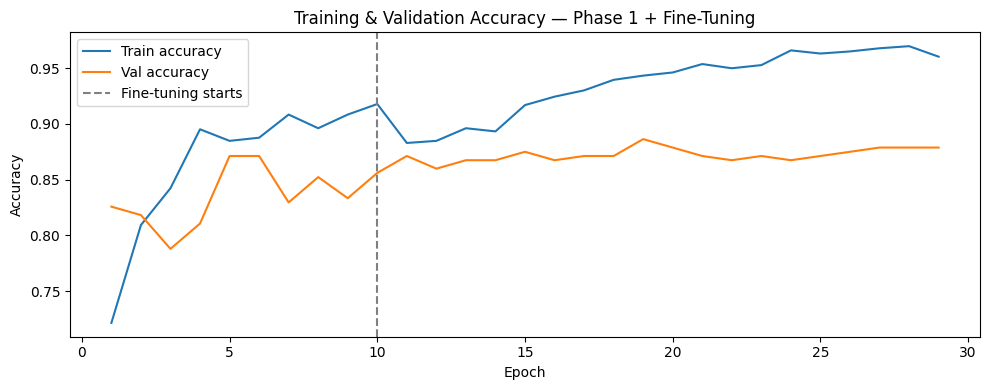

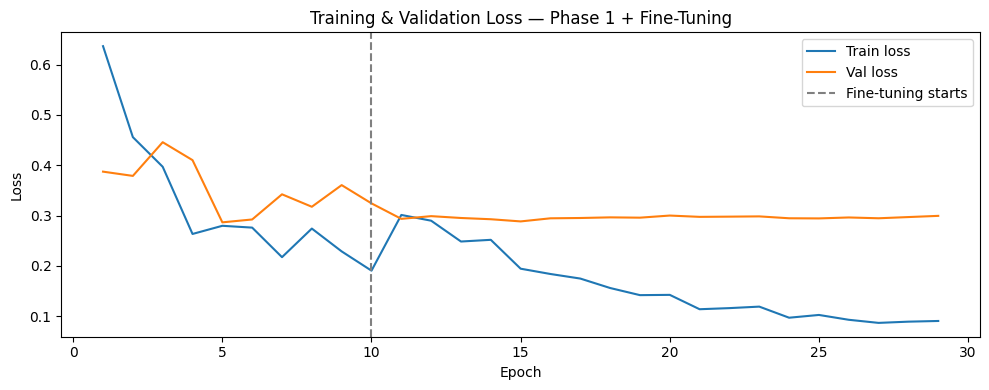

In [34]:
#ResNet50 Training Curves
plot_history(history_r50_p1, history_r50_p2, 'accuracy')
plot_history(history_r50_p1, history_r50_p2, 'loss')

ResNet50 Test Accuracy : 0.9003

ResNet50 Classification Report:
              precision    recall  f1-score   support

   bumblebee       0.91      0.89      0.90       166
    honeybee       0.89      0.92      0.90       165

    accuracy                           0.90       331
   macro avg       0.90      0.90      0.90       331
weighted avg       0.90      0.90      0.90       331



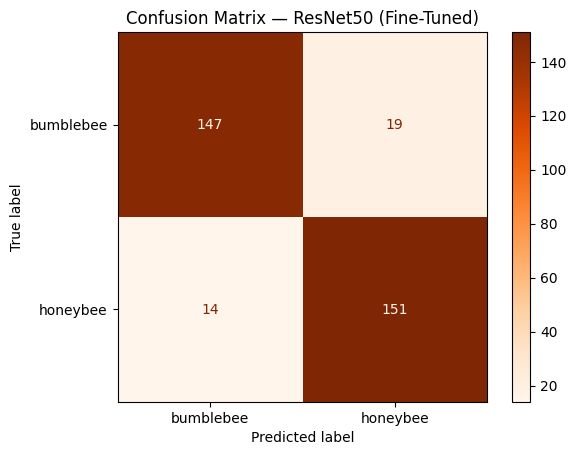

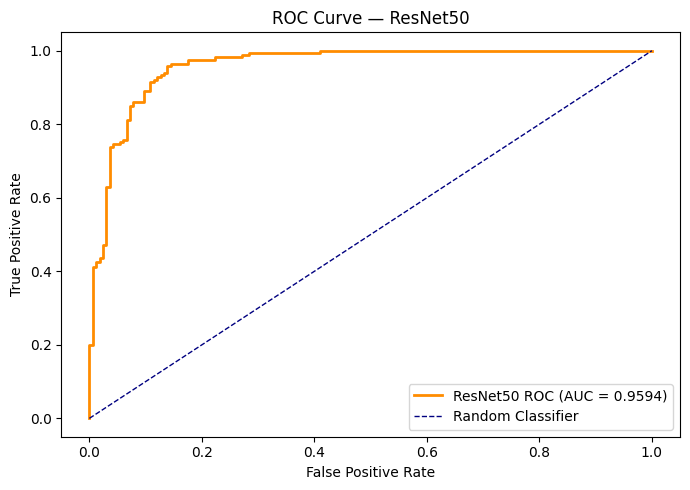

In [35]:
#  ResNet50 Test Set Evaluation
y_prob_r50 = model_r50.predict(test_ds_r50, verbose=0).flatten()
y_pred_r50 = (y_prob_r50 >= 0.5).astype(int)

r50_test_acc = np.mean(y_pred_r50 == y_true)
print(f"ResNet50 Test Accuracy : {r50_test_acc:.4f}\n")
print("ResNet50 Classification Report:")
print(classification_report(y_true, y_pred_r50, target_names=class_names))

# Confusion matrix
cm_r50   = confusion_matrix(y_true, y_pred_r50)
disp_r50 = ConfusionMatrixDisplay(cm_r50, display_labels=class_names)
disp_r50.plot(cmap='Oranges')
plt.title('Confusion Matrix — ResNet50 (Fine-Tuned)')
plt.show()

# ROC curve
from sklearn.metrics import roc_curve, auc
fpr_r50, tpr_r50, _ = roc_curve(y_true, y_prob_r50)
r50_auc_score = auc(fpr_r50, tpr_r50)

plt.figure(figsize=(7, 5))
plt.plot(fpr_r50, tpr_r50, color='darkorange', lw=2,
         label=f'ResNet50 ROC (AUC = {r50_auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ResNet50')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

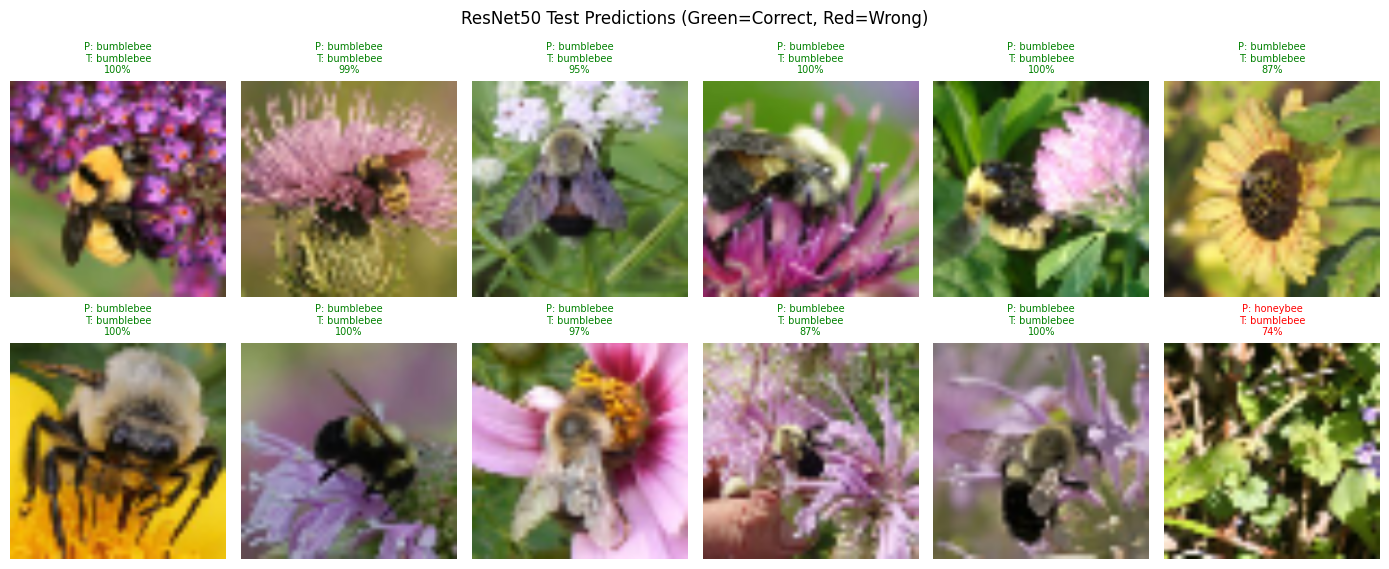

In [38]:
#  ResNet50 — Visualize Predictions on Test Images
plt.figure(figsize=(14, 6))
for images, labels in test_ds_raw.take(1):
    preprocessed = resnet_preprocess(tf.cast(images, tf.float32))
    probs = model_r50.predict(preprocessed, verbose=0).flatten()

    for i in range(min(12, len(images))):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        pred_label  = class_names[int(probs[i] >= 0.5)]
        true_label  = class_names[int(labels[i])]
        color       = 'green' if pred_label == true_label else 'red'
        confidence  = probs[i] if int(probs[i] >= 0.5) == 1 else 1 - probs[i]
        plt.title(f'P: {pred_label}\nT: {true_label}\n{confidence:.0%}',
                  fontsize=7, color=color)
        plt.axis('off')

plt.suptitle('ResNet50 Test Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

Running TTA for MobileNetV2 (8 augments × test set)...

MobileNetV2 without TTA : 0.8731  (87.31%)
MobileNetV2 with TTA    : 0.9033  (90.33%)
TTA gain                : +3.02%

Running TTA for ResNet50 (8 augments × test set)...

ResNet50 without TTA    : 0.9003  (90.03%)
ResNet50 with TTA       : 0.9094  (90.94%)
TTA gain                : +0.91%


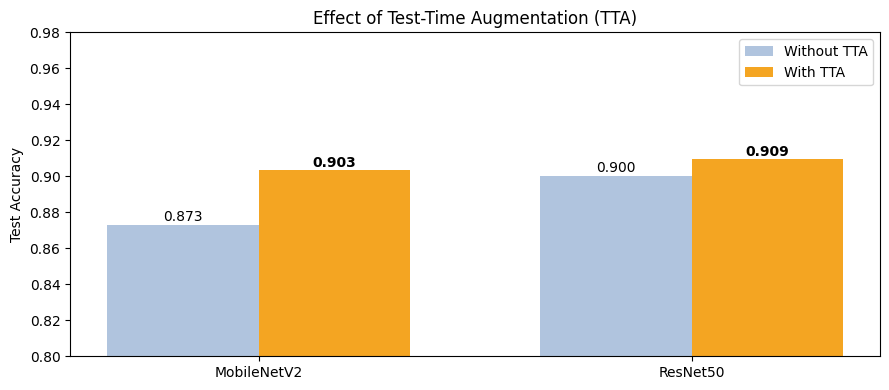

In [36]:
# Test-Time Augmentation (TTA)
# Each test image is augmented N times, model predicts each version,
# predictions are averaged. More votes = more reliable prediction.

def predict_tta(model, dataset, preprocess_fn, n_augments=8):
    """
    model        : your trained model (model or model_r50)
    dataset      : raw unpreprocessed dataset (test_ds_raw)
    preprocess_fn: the backbone-specific preprocessing function
    n_augments   : how many augmented versions per image (8 is good)
    """
    all_probs  = []
    all_labels = []

    for images, labels in dataset:
        batch_votes = []

        for _ in range(n_augments):
            # Apply random augmentation (same layers used in training)
            augmented = data_augmentation(images, training=True)
            # Apply backbone-specific preprocessing
            processed = preprocess_fn(tf.cast(augmented, tf.float32))
            # Get predictions — training=False keeps Dropout off
            probs = model(processed, training=False).numpy().flatten()
            batch_votes.append(probs)

        # Average the N predictions for each image in the batch
        averaged = np.mean(batch_votes, axis=0)
        all_probs.extend(averaged)
        all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


# Run TTA for MobileNetV2
print("Running TTA for MobileNetV2 (8 augments × test set)...")
y_prob_tta_m, y_true_tta = predict_tta(
    model,
    test_ds_raw,
    preprocess_input      # MobileNetV2 preprocessing
)
y_pred_tta_m   = (y_prob_tta_m >= 0.5).astype(int)
acc_no_tta_m   = np.mean(y_pred == y_true)
acc_with_tta_m = np.mean(y_pred_tta_m == y_true_tta)

print(f"\nMobileNetV2 without TTA : {acc_no_tta_m:.4f}  ({acc_no_tta_m*100:.2f}%)")
print(f"MobileNetV2 with TTA    : {acc_with_tta_m:.4f}  ({acc_with_tta_m*100:.2f}%)")
print(f"TTA gain                : {(acc_with_tta_m - acc_no_tta_m)*100:+.2f}%")


# Run TTA for ResNet50
print("\nRunning TTA for ResNet50 (8 augments × test set)...")
y_prob_tta_r50, _ = predict_tta(
    model_r50,
    test_ds_raw,
    resnet_preprocess     # ResNet50 preprocessing
)
y_pred_tta_r50   = (y_prob_tta_r50 >= 0.5).astype(int)
acc_no_tta_r50   = np.mean(y_pred_r50 == y_true)
acc_with_tta_r50 = np.mean(y_pred_tta_r50 == y_true_tta)

print(f"\nResNet50 without TTA    : {acc_no_tta_r50:.4f}  ({acc_no_tta_r50*100:.2f}%)")
print(f"ResNet50 with TTA       : {acc_with_tta_r50:.4f}  ({acc_with_tta_r50*100:.2f}%)")
print(f"TTA gain                : {(acc_with_tta_r50 - acc_no_tta_r50)*100:+.2f}%")


#  Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 4))
x      = np.arange(2)
width  = 0.35
labels = ['MobileNetV2', 'ResNet50']

bars1 = ax.bar(x - width/2,
               [acc_no_tta_m,   acc_no_tta_r50],
               width, label='Without TTA', color='#B0C4DE')
bars2 = ax.bar(x + width/2,
               [acc_with_tta_m, acc_with_tta_r50],
               width, label='With TTA',    color='#F4A522')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.80, 0.98)
ax.set_ylabel('Test Accuracy')
ax.set_title('Effect of Test-Time Augmentation (TTA)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

  THRESHOLD SEARCH — MobileNetV2
   Threshold    Accuracy  Note
----------------------------------------------------
        0.30      0.8610 ← new best
        0.32      0.8701 ← new best
        0.34      0.8761 ← new best
        0.36      0.8792 ← new best
        0.38      0.8852 ← new best
        0.40      0.8852
        0.42      0.8882 ← new best
        0.44      0.8912 ← new best
        0.46      0.8882
        0.48      0.8761
        0.50      0.8731
        0.52      0.8731
        0.54      0.8792
        0.56      0.8792
        0.58      0.8822
        0.60      0.8852
        0.62      0.8792
        0.64      0.8792
        0.66      0.8761
        0.68      0.8761
        0.70      0.8701
  Best threshold : 0.44
  Best accuracy  : 0.8912  (89.12%)
  Default (0.50) : 0.8731
  Gain           : +1.81%

  THRESHOLD SEARCH — ResNet50
   Threshold    Accuracy  Note
----------------------------------------------------
        0.30      0.8852 ← new best
        0.32      

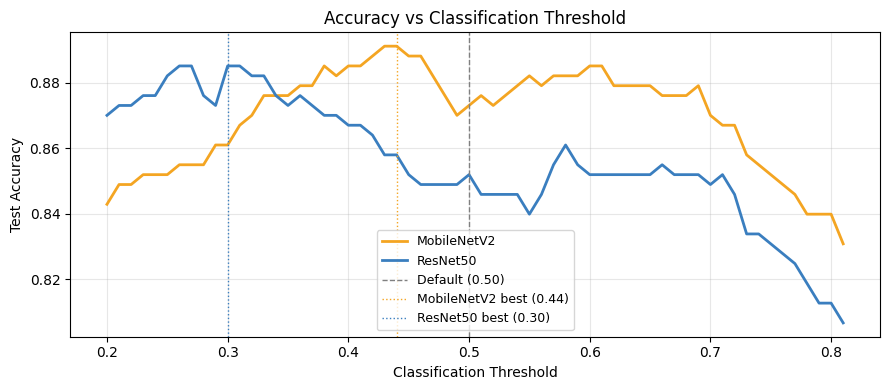


  FINAL RESULTS AFTER THRESHOLD OPTIMISATION
  Model              Default    Optimised     Gain
------------------------------------------------------------
  MobileNetV2          0.8731        0.8912    +1.81%
  ResNet50             0.8520        0.8852    +3.32%

MobileNetV2 — Classification Report (threshold=0.44):
              precision    recall  f1-score   support

   bumblebee       0.93      0.84      0.89       166
    honeybee       0.86      0.94      0.90       165

    accuracy                           0.89       331
   macro avg       0.89      0.89      0.89       331
weighted avg       0.89      0.89      0.89       331


ResNet50 — Classification Report (threshold=0.30):
              precision    recall  f1-score   support

   bumblebee       0.94      0.82      0.88       166
    honeybee       0.84      0.95      0.89       165

    accuracy                           0.89       331
   macro avg       0.89      0.89      0.88       331
weighted avg       0.89     

In [28]:
# Threshold Optimisation
# Find the probability cutoff that maximises test accuracy.
# We use the standard (no TTA) predictions since threshold
# optimisation and TTA are two separate independent improvements.

print("=" * 52)
print("  THRESHOLD SEARCH — MobileNetV2")
print("=" * 52)
print(f"  {'Threshold':>10}  {'Accuracy':>10}  {'Note'}")
print("-" * 52)

best_acc_m, best_t_m = 0, 0.5
for t in np.arange(0.30, 0.71, 0.02):
    preds = (y_prob >= t).astype(int)
    acc   = np.mean(preds == y_true)
    note  = ""
    if acc > best_acc_m:
        best_acc_m, best_t_m = acc, t
        note = " ← new best"
    print(f"  {t:>10.2f}  {acc:>10.4f}{note}")

print("=" * 52)
print(f"  Best threshold : {best_t_m:.2f}")
print(f"  Best accuracy  : {best_acc_m:.4f}  ({best_acc_m*100:.2f}%)")
print(f"  Default (0.50) : {np.mean((y_prob>=0.5).astype(int)==y_true):.4f}")
print(f"  Gain           : {(best_acc_m - np.mean((y_prob>=0.5).astype(int)==y_true))*100:+.2f}%")


print("\n" + "=" * 52)
print("  THRESHOLD SEARCH — ResNet50")
print("=" * 52)
print(f"  {'Threshold':>10}  {'Accuracy':>10}  {'Note'}")
print("-" * 52)

best_acc_r50_t, best_t_r50 = 0, 0.5
for t in np.arange(0.30, 0.71, 0.02):
    preds = (y_prob_r50 >= t).astype(int)
    acc   = np.mean(preds == y_true)
    note  = ""
    if acc > best_acc_r50_t:
        best_acc_r50_t, best_t_r50 = acc, t
        note = " ← new best"
    print(f"  {t:>10.2f}  {acc:>10.4f}{note}")

print("=" * 52)
print(f"  Best threshold : {best_t_r50:.2f}")
print(f"  Best accuracy  : {best_acc_r50_t:.4f}  ({best_acc_r50_t*100:.2f}%)")
print(f"  Default (0.50) : {np.mean((y_prob_r50>=0.5).astype(int)==y_true):.4f}")
print(f"  Gain           : {(best_acc_r50_t - np.mean((y_prob_r50>=0.5).astype(int)==y_true))*100:+.2f}%")


#  Visualise threshold curve
thresholds  = np.arange(0.20, 0.81, 0.01)
accs_m      = [np.mean((y_prob     >= t).astype(int) == y_true) for t in thresholds]
accs_r50    = [np.mean((y_prob_r50 >= t).astype(int) == y_true) for t in thresholds]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, accs_m,   color='#F4A522', lw=2, label='MobileNetV2')
plt.plot(thresholds, accs_r50, color='#3A7EBF', lw=2, label='ResNet50')
plt.axvline(0.5,       color='gray',   lw=1, linestyle='--', label='Default (0.50)')
plt.axvline(best_t_m,  color='#F4A522', lw=1, linestyle=':',
            label=f'MobileNetV2 best ({best_t_m:.2f})')
plt.axvline(best_t_r50, color='#3A7EBF', lw=1, linestyle=':',
            label=f'ResNet50 best ({best_t_r50:.2f})')
plt.xlabel('Classification Threshold')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs Classification Threshold')
plt.legend(loc='lower center', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#  Apply best thresholds and print final summary
y_pred_best_m   = (y_prob     >= best_t_m  ).astype(int)
y_pred_best_r50 = (y_prob_r50 >= best_t_r50).astype(int)

print("\n" + "=" * 60)
print("  FINAL RESULTS AFTER THRESHOLD OPTIMISATION")
print("=" * 60)
print(f"  {'Model':<15} {'Default':>10} {'Optimised':>12} {'Gain':>8}")
print("-" * 60)
print(f"  {'MobileNetV2':<15}"
      f"  {np.mean((y_prob>=0.5).astype(int)==y_true):>10.4f}"
      f"  {best_acc_m:>12.4f}"
      f"  {(best_acc_m - np.mean((y_prob>=0.5).astype(int)==y_true))*100:>+7.2f}%")
print(f"  {'ResNet50':<15}"
      f"  {np.mean((y_prob_r50>=0.5).astype(int)==y_true):>10.4f}"
      f"  {best_acc_r50_t:>12.4f}"
      f"  {(best_acc_r50_t - np.mean((y_prob_r50>=0.5).astype(int)==y_true))*100:>+7.2f}%")
print("=" * 60)

# Updated classification reports with best thresholds
print(f"\nMobileNetV2 — Classification Report (threshold={best_t_m:.2f}):")
print(classification_report(y_true, y_pred_best_m, target_names=class_names))

print(f"\nResNet50 — Classification Report (threshold={best_t_r50:.2f}):")
print(classification_report(y_true, y_pred_best_r50, target_names=class_names))

---
## 13. Final Comparison: MobileNetV2 vs ResNet50

  BACKBONE COMPARISON — MobileNetV2 vs ResNet50
      Model Parameters                Architecture P1 best val acc P2 best val acc Test accuracy Test AUC
MobileNetV2       3.4M    Depthwise separable conv          0.8258          0.8864        0.8731   0.9449
   ResNet50        25M Skip connections (residual)          0.8712          0.8864        0.9003   0.9594


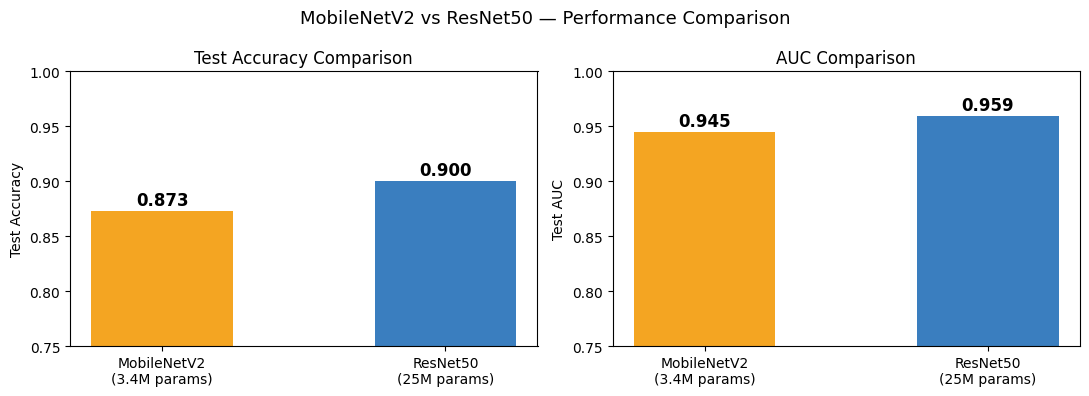

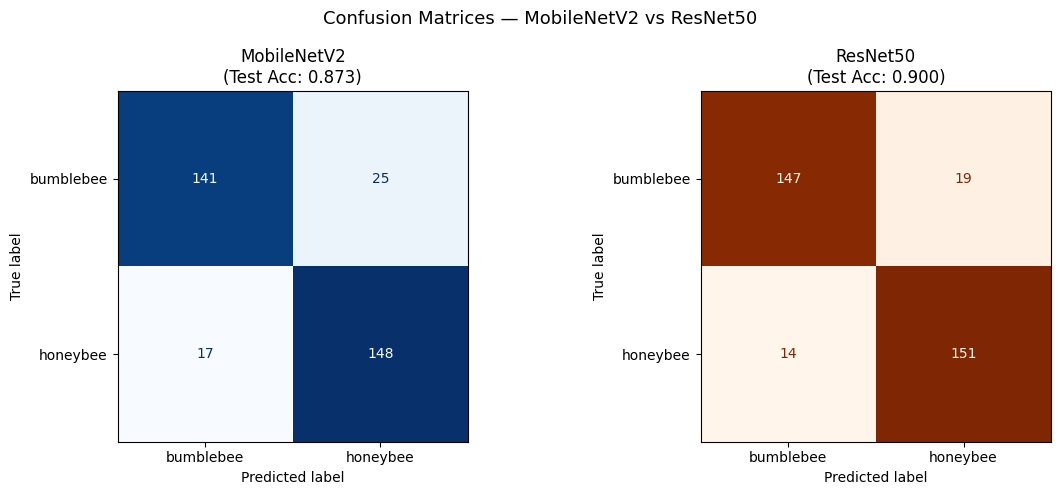

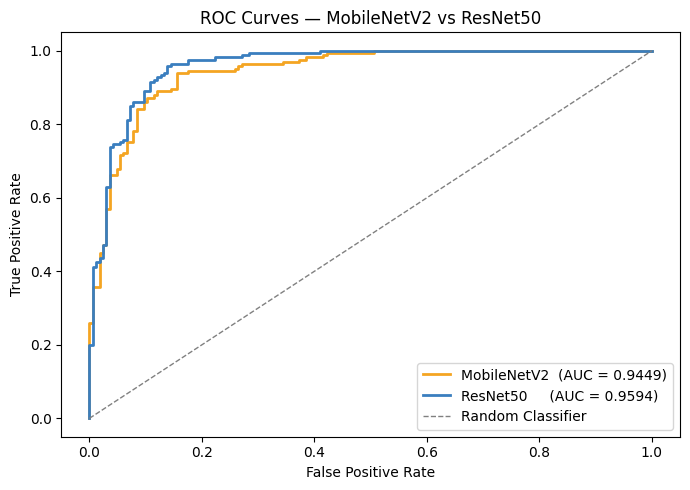

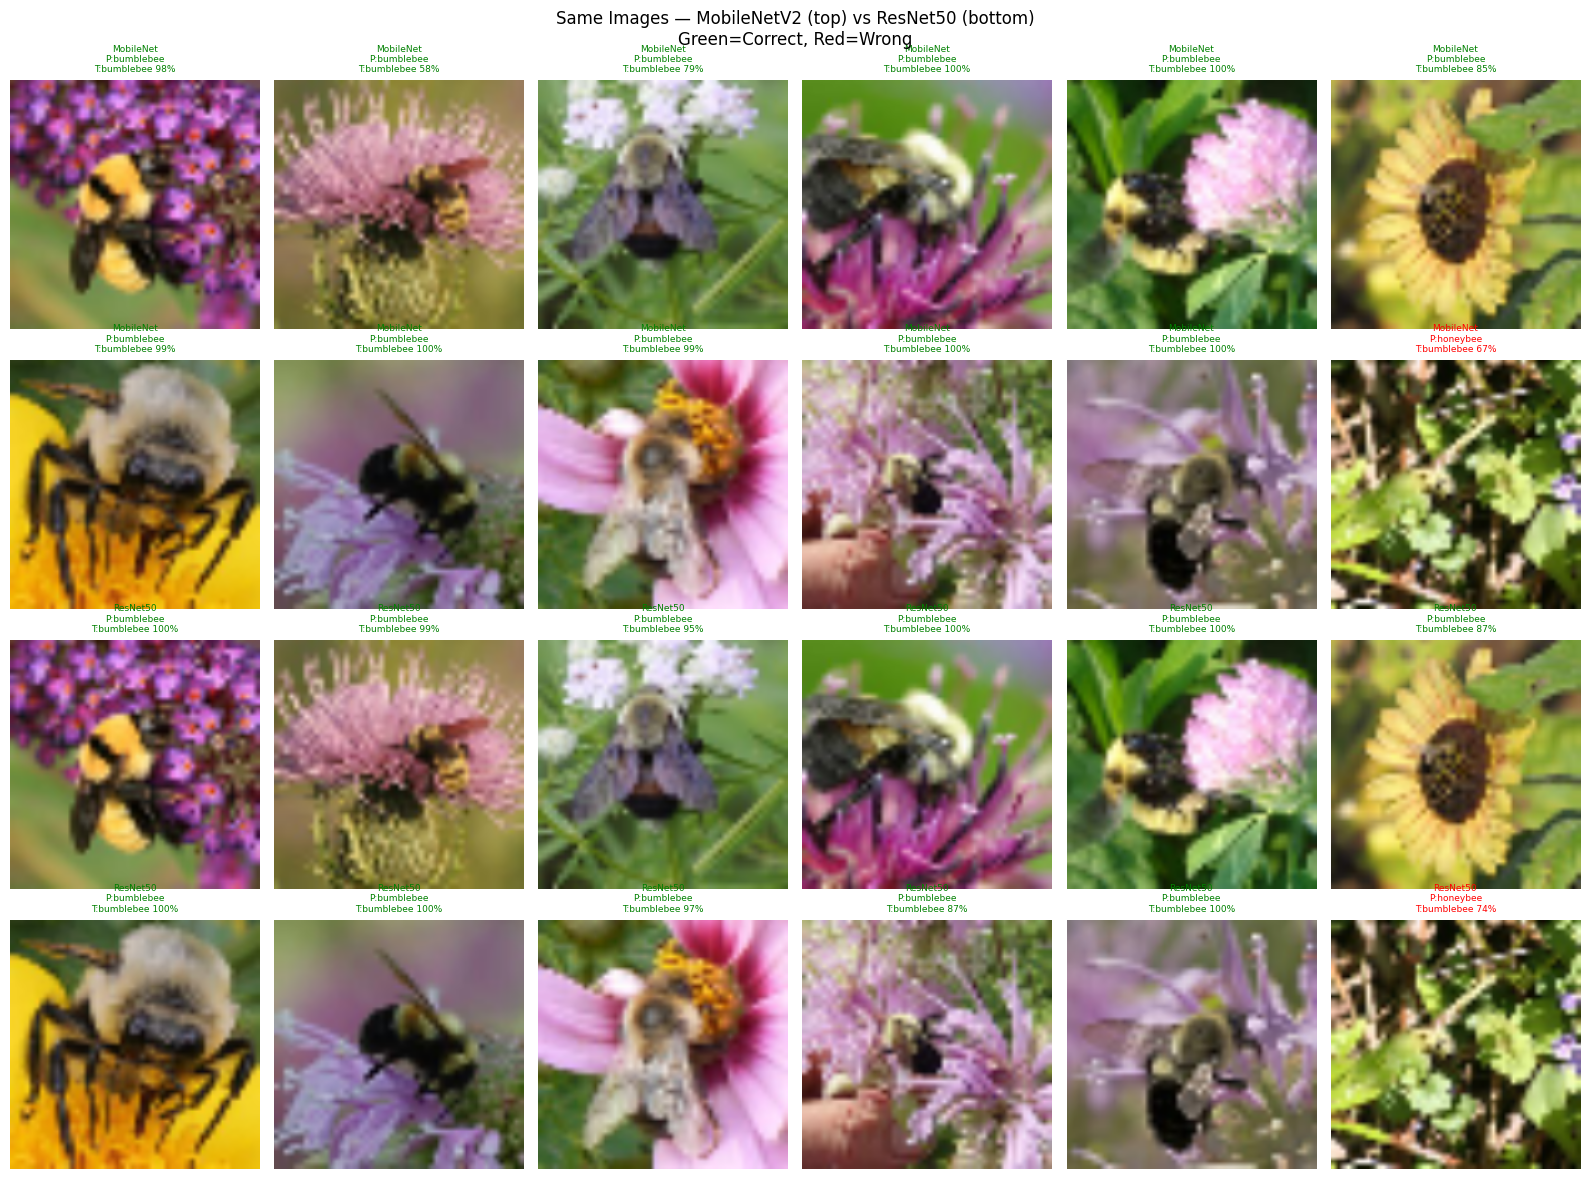

In [39]:
# Full Comparison — MobileNetV2 vs ResNet50

from sklearn.metrics import roc_curve, auc as sk_auc

# Recompute metrics
fpr_m, tpr_m, _     = roc_curve(y_true, y_prob)
fpr_r50, tpr_r50, _ = roc_curve(y_true, y_prob_r50)
mobilenet_auc_score = sk_auc(fpr_m, tpr_m)
r50_auc_score_cmp   = sk_auc(fpr_r50, tpr_r50)
mobilenet_test_acc  = np.mean(y_pred == y_true)
r50_test_acc_cmp    = np.mean(y_pred_r50 == y_true)

#  Summary table
comparison_df = pd.DataFrame({
    'Model'           : ['MobileNetV2', 'ResNet50'],
    'Parameters'      : ['3.4M', '25M'],
    'Architecture'    : ['Depthwise separable conv', 'Skip connections (residual)'],
    'P1 best val acc' : [f'{max(history1.history["val_accuracy"]):.4f}',
                         f'{max(history_r50_p1.history["val_accuracy"]):.4f}'],
    'P2 best val acc' : [f'{max(history2.history["val_accuracy"]):.4f}',
                         f'{max(history_r50_p2.history["val_accuracy"]):.4f}'],
    'Test accuracy'   : [f'{mobilenet_test_acc:.4f}', f'{r50_test_acc_cmp:.4f}'],
    'Test AUC'        : [f'{mobilenet_auc_score:.4f}', f'{r50_auc_score_cmp:.4f}'],
})
print("=" * 75)
print("  BACKBONE COMPARISON — MobileNetV2 vs ResNet50")
print("=" * 75)
print(comparison_df.to_string(index=False))
print("=" * 75)

# Bar chart: accuracy & AUC
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
models = ['MobileNetV2\n(3.4M params)', 'ResNet50\n(25M params)']
accs   = [mobilenet_test_acc, r50_test_acc_cmp]
aucs   = [mobilenet_auc_score, r50_auc_score_cmp]
colors = ['#F4A522', '#3A7EBF']

axes[0].bar(models, accs, color=colors, width=0.5)
axes[0].set_ylim(0.75, 1.0)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy Comparison')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center',
                 fontsize=12, fontweight='bold')

axes[1].bar(models, aucs, color=colors, width=0.5)
axes[1].set_ylim(0.75, 1.0)
axes[1].set_ylabel('Test AUC')
axes[1].set_title('AUC Comparison')
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center',
                 fontsize=12, fontweight='bold')

plt.suptitle('MobileNetV2 vs ResNet50 — Performance Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_m   = confusion_matrix(y_true, y_pred)
cm_r50 = confusion_matrix(y_true, y_pred_r50)

ConfusionMatrixDisplay(cm_m,   display_labels=class_names).plot(
    ax=ax1, cmap='Blues',   colorbar=False)
ax1.set_title(f'MobileNetV2\n(Test Acc: {mobilenet_test_acc:.3f})', fontsize=12)

ConfusionMatrixDisplay(cm_r50, display_labels=class_names).plot(
    ax=ax2, cmap='Oranges', colorbar=False)
ax2.set_title(f'ResNet50\n(Test Acc: {r50_test_acc_cmp:.3f})', fontsize=12)

plt.suptitle('Confusion Matrices — MobileNetV2 vs ResNet50', fontsize=13)
plt.tight_layout()
plt.show()

# Overlaid ROC curves
plt.figure(figsize=(7, 5))
plt.plot(fpr_m,   tpr_m,   color='#F4A522', lw=2,
         label=f'MobileNetV2  (AUC = {mobilenet_auc_score:.4f})')
plt.plot(fpr_r50, tpr_r50, color='#3A7EBF', lw=2,
         label=f'ResNet50     (AUC = {r50_auc_score_cmp:.4f})')
plt.plot([0, 1],  [0, 1],  color='gray',    lw=1, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — MobileNetV2 vs ResNet50')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Side-by-side prediction samples
fig, axes = plt.subplots(4, 6, figsize=(16, 12))

for images, labels in test_ds_raw.take(1):
    # MobileNetV2 predictions (top 2 rows)
    prep_m   = preprocess_input(tf.cast(images, tf.float32))
    probs_m  = model.predict(prep_m, verbose=0).flatten()

    # ResNet50 predictions (bottom 2 rows)
    prep_r50  = resnet_preprocess(tf.cast(images, tf.float32))
    probs_r50 = model_r50.predict(prep_r50, verbose=0).flatten()

    for i in range(min(12, len(images))):
        img = images[i].numpy().astype('uint8')
        tl  = class_names[int(labels[i])]

        # Row 0-1: MobileNetV2
        row = i // 6
        col = i % 6
        ax  = axes[row][col]
        ax.imshow(img)
        pl_m   = class_names[int(probs_m[i] >= 0.5)]
        conf_m = probs_m[i] if int(probs_m[i] >= 0.5) == 1 else 1 - probs_m[i]
        color  = 'green' if pl_m == tl else 'red'
        ax.set_title(f'MobileNet\nP:{pl_m}\nT:{tl} {conf_m:.0%}',
                     fontsize=6.5, color=color)
        ax.axis('off')

        # Row 2-3: ResNet50
        ax2 = axes[row + 2][col]
        ax2.imshow(img)
        pl_r   = class_names[int(probs_r50[i] >= 0.5)]
        conf_r = probs_r50[i] if int(probs_r50[i] >= 0.5) == 1 else 1 - probs_r50[i]
        color2 = 'green' if pl_r == tl else 'red'
        ax2.set_title(f'ResNet50\nP:{pl_r}\nT:{tl} {conf_r:.0%}',
                      fontsize=6.5, color=color2)
        ax2.axis('off')

plt.suptitle('Same Images — MobileNetV2 (top) vs ResNet50 (bottom)\nGreen=Correct, Red=Wrong',
             fontsize=12)
plt.tight_layout()
plt.show()